# Loaded-Dice — a quantitative teardown 🔬
### Real 5-minute tape · barrier backtest · random-direction control · HAC inference · turnover costs

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Beats a coin%3F: Busted](https://img.shields.io/badge/Beats_a_coin%3F-Busted-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We test whether the SMA(5/10) crossover direction beats a random-direction control on a symmetric-barrier backtest, across eight liquid 5-minute tapes, and what turnover does to it.

> ⚠️ **Not investment advice.** Real data: Yahoo 5-minute bars, ~60-day rolling window, as-of 2026-06-12; the offline core and tests run on a deterministic synthetic tape. Methods & sources in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from loaded_dice import data, strategy as st

TICKERS = ["SPY", "QQQ", "IWM", "AAPL", "TSLA", "NVDA", "ES=F", "NQ=F"]

def _have_cache():
    return all(os.path.exists(data._cache_path(t, data.DEFAULT_CACHE)) for t in TICKERS)

HAVE_REAL = _have_cache()

def pooled(tp, sl, cost, seed=None):
    """Pool barrier trades across the basket (cached real tapes)."""
    frames = []
    for t in TICKERS:
        b = data.fetch_5m(t, fetch=False)
        ent = st.crossover_entries(b["close"])
        dirs = st.random_directions(len(ent), seed=seed) if seed is not None else None
        frames.append(st.run_trades(b, ent, tp_R=tp, sl_R=sl, cost_bps=cost, directions=dirs))
    return pd.concat(frames, ignore_index=True)

print("real 5m cache present:" , HAVE_REAL)

from quantlab import analytics, stats


real 5m cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Cross gross **-0.39 bps/trade**, HAC *t* = **-1.12**; no edge over a random-direction control (Δ = -0.53 bps). |
| **Tradability** | `MIRAGE` | ~11.3 trades/day → significant loser at 1 bp (*t* = -3.98), **-40%/yr** net. |
| **Beats a coin?** | `BUSTED` | Fixed-tick arm: win **93.5%**, skew **-8.0**, mean *t* = +1.35 — a skew illusion. |

> 💡 Three failures, one cause: there is no exploitable serial dependence in 5-minute returns at this horizon, so the rule is a fair (slightly tax-disadvantaged) die.

## 1 · The claim, steelmanned

Let $r_t$ be the bar log-return and $x_t = \mathrm{sign}(\mathrm{SMA}_5 - \mathrm{SMA}_{10})_t$ the crossover state. The recipe asserts:

- **H₁ (signal).** $\mathbb{E}[\,d\cdot r_{t\to\text{exit}}\,] > 0$ where $d$ is the cross direction — i.e. the cross carries directional information, *measured symmetrically* so a coin scores 0.
- **H₂ (beats random).** That expectation exceeds the same statistic with $d$ replaced by an i.i.d. fair coin on identical entries.
- **H₃ (tradable).** It survives a realistic round-trip cost at the rule's natural turnover.

We reject H₁ and H₂ on the real tape and H₃ trivially.

## 2 · So what? — what rides on each answer

The crossover scalp is the most-recommended retail intraday rule there is. If H₁–H₃ held, it would be a rare free lunch. The interesting failure isn't *that* it loses — it's *how*: the win-rate the recipe sells (90%+) is real and completely uninformative, a textbook demonstration that **win-rate is not expectancy** once the exit is asymmetric and the P&L is skewed.

## 3 · How we'd know — the protocol

- **Entry.** Cross of SMA(5)/SMA(10) on closes up to $t$; **enter at $t{+}1$'s open** (no look-ahead).
- **Exit (symmetric).** Barriers at $\pm 1\,\mathrm{ATR}(20)$ from entry; flat at the 16:00 close; a bar that straddles both barriers is filled at the **stop** (conservative).
- **Control.** Identical entries, direction $\in\{-1,+1\}$ drawn i.i.d. (seeded).
- **Inference.** Newey–West HAC *t* on per-trade returns; circular block-bootstrap Sharpe CI; per-instrument breakdown; a cost sweep at the rule's turnover.
- **Positive control.** A synthetic tape with a tunable bar-level AR(1) momentum, to confirm the engine recovers an edge *when one exists*.

Eight tapes: SPY, QQQ, IWM, AAPL, TSLA, NVDA, ES=F, NQ=F.

## 4 · The teardown

### 4a · The symmetric bet, per instrument — no tape carries a signal

Per-instrument HAC *t* on the gross per-trade return. If the rule worked anywhere, a bar would clear +2.

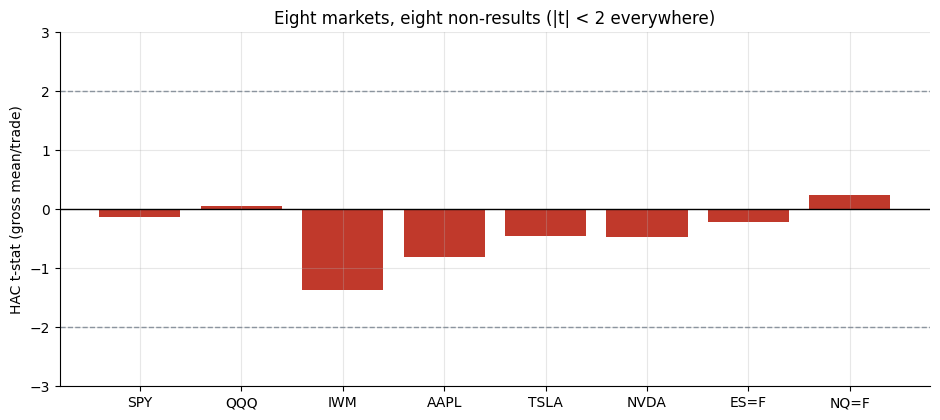

pooled: -0.39 bps/trade, HAC t = -1.12


,ticker,n,win%,mean_bps,t
0,SPY,497,50.91,-0.06,-0.13
1,QQQ,491,49.90,0.05,0.06
2,IWM,532,46.80,-0.93,-1.36
3,AAPL,519,49.90,-0.69,-0.80
4,TSLA,485,49.48,-0.71,-0.45
5,NVDA,473,49.68,-0.70,-0.47
6,ES=F,404,51.24,-0.11,-0.22
7,NQ=F,400,49.75,0.20,0.24


In [2]:
if HAVE_REAL:
    recs = []
    for t in TICKERS:
        b = data.fetch_5m(t, fetch=False); ent = st.crossover_entries(b['close'])
        s = st.summarize(st.run_trades(b, ent, tp_R=1, sl_R=1, cost_bps=0), 'ret_gross')
        recs.append((t, s['n_trades'], s['win_rate']*100, s['mean_bps'], s['tstat']))
    perinst = pd.DataFrame(recs, columns=['ticker','n','win%','mean_bps','t'])
    p = pooled(1,1,0); ps = st.summarize(p,'ret_gross')
else:
    perinst = pd.DataFrame({'ticker':TICKERS,
        't':[-0.13,0.06,-1.36,-0.80,-0.45,-0.47,-0.22,0.24]})
    perinst['mean_bps']=np.nan; perinst['win%']=np.nan; perinst['n']=np.nan
    ps = dict(mean_bps=R['cross_mean'], tstat=R['cross_t'], win_rate=R['cross_win']/100)
fig, ax = plt.subplots(figsize=(9.5, 4.3))
col = [RED if abs(v)<2 else GREEN for v in perinst['t']]
ax.bar(perinst['ticker'], perinst['t'], color=col)
for s in (2,-2): ax.axhline(s, ls='--', c=GREY, lw=1)
ax.axhline(0, c='k', lw=1); ax.set_ylabel('HAC t-stat (gross mean/trade)')
ax.set_title('Eight markets, eight non-results (|t| < 2 everywhere)')
ax.set_ylim(-3, 3); plt.tight_layout(); plt.show()
print(f"pooled: {ps['mean_bps']:+.2f} bps/trade, HAC t = {ps['tstat']:+.2f}")
perinst.round(2)

> 💡 Every instrument sits inside the ±2 band, most of them *below* zero. Pooling 3,801 trades gives **-0.39 bps**, HAC *t* = **-1.12** — the extra power of pooling buys us confidence that the edge is *absent*, not merely noisy.

### 4b · Crossover vs the coin — same bet, with a bootstrap band

The random-direction control on identical entries, with a circular block-bootstrap 95% CI on the annualised Sharpe of the crossover arm.

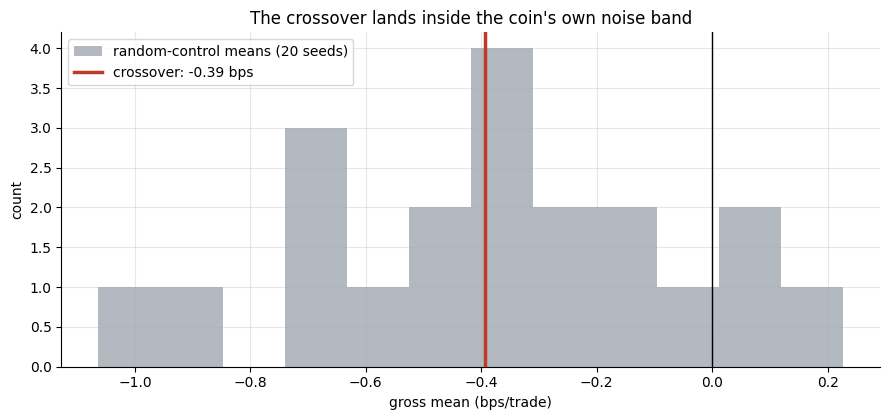

annualised Sharpe 95% CI: [-2.39, +0.69]  (88% of resamples < 0)


In [3]:
if HAVE_REAL:
    C = pooled(1,1,0); cm = st.summarize(C,'ret_gross')
    rand_means = [st.summarize(pooled(1,1,0,seed=s),'ret_gross')['mean_bps'] for s in range(20)]
    tpy = int(round(cm['n_trades']/len(TICKERS)/42*252))
    ci = stats.sharpe_ci_bootstrap(pd.Series(C['ret_gross'].values), periods_per_year=tpy, seed=72)
    cmean, clo, chi, fn = cm['mean_bps'], ci['ci_low'], ci['ci_high'], ci['frac_negative']*100
else:
    rand_means=[R['rand_mean']]; cmean,clo,chi,fn = R['cross_mean'],R['ci_lo'],R['ci_hi'],R['frac_neg']
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(rand_means, bins=12, color=GREY, alpha=.65, label='random-control means (20 seeds)')
ax.axvline(cmean, c=RED, lw=2.5, label=f'crossover: {cmean:+.2f} bps')
ax.axvline(0, c='k', lw=1)
ax.set_xlabel('gross mean (bps/trade)'); ax.set_ylabel('count')
ax.set_title('The crossover lands inside the coin\'s own noise band'); ax.legend()
plt.tight_layout(); plt.show()
print(f'annualised Sharpe 95% CI: [{clo:+.2f}, {chi:+.2f}]  ({fn:.0f}% of resamples < 0)')

The crossover's gross Sharpe is **-0.91**, bootstrap 95% CI **[-2.39, +0.69]** (88% of resamples negative). It is statistically indistinguishable from — and point-estimate *worse* than — a coin.

### 4c · The fixed-tick illusion — win-rate ≠ expectancy

Shrink the target, widen the stop: the win-rate climbs to the famous 90s, the skew collapses, and the mean stays pinned at noise.

In [4]:
specs = [('1.0R/1.0R', 1.0,1.0), ('0.5R/2.0R', 0.5,2.0), ('0.25R/8R', 0.25,8.0)]
if HAVE_REAL:
    tt = [(l,)+tuple(st.summarize(pooled(tp,sl,0),'ret_gross')[k] for k in ('win_rate','mean_bps','skew','tstat')) for l,tp,sl in specs]
    tt = pd.DataFrame(tt, columns=['rule','win','mean_bps','skew','t']); tt['win']*=100
else:
    tt = pd.DataFrame({'rule':['1.0R/1.0R','0.5R/2.0R','0.25R/8R'],
        'win':[R['cross_win'],R['naive14_win'],R['nostop_win']],
        'mean_bps':[R['cross_mean'],R['naive14_mean'],R['nostop_mean']],
        'skew':[R['cross_skew'],R['naive14_skew'],R['nostop_skew']],
        't':[R['cross_t'],R['naive14_t'],R['nostop_t']]})
tt.round(2)

,rule,win,mean_bps,skew,t
0,1.0R/1.0R,49.64,-0.39,-0.00,-1.12
1,0.5R/2.0R,80.08,0.40,-2.37,1.20
2,0.25R/8R,93.50,0.47,-8.03,1.35


> 💡 The win-rate is a deterministic function of the barrier ratio, not of any forecasting skill: with target $a$ and stop $b$ on a driftless path the hit-probability of the target is ≈ $b/(a+b)$. Set $b=8a$ and you 'win' ~89% by construction — while the expectancy stays zero and the variance migrates entirely into the left tail (skew **-8.0**).

## 5 · The verdict

- **Signal `NONE`** — pooled gross -0.39 bps/trade, HAC *t* -1.12; Δ vs control -0.53 bps; every instrument |*t*| < 1.4.
- **Tradability `MIRAGE`** — gross Sharpe -0.91; net *t* -3.98 at 1 bp; -40%/yr.
- **Beats a coin? `BUSTED`** — 93.5% win-rate at skew -8.0, mean *t* +1.35.

## 6 · Could you trade it? — turnover does the killing

Per-trade net mean and its HAC *t* across round-trip cost, at ~11 trades/day.

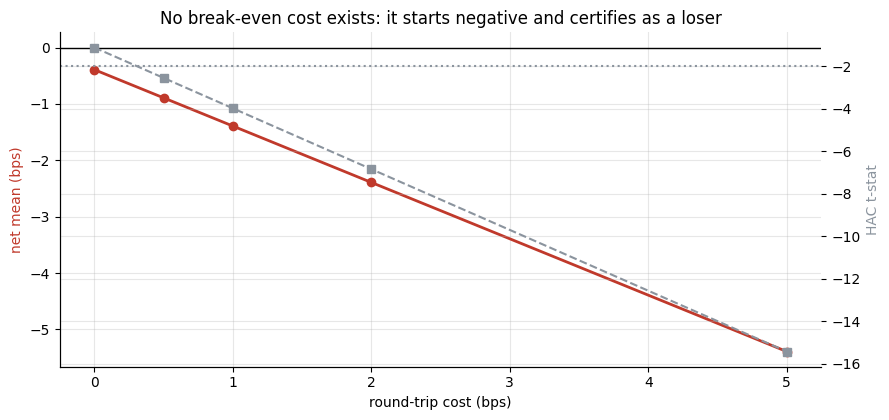

break-even round-trip cost: none (gross is already below zero)


In [5]:
costs = [0.0,0.5,1.0,2.0,5.0]
if HAVE_REAL:
    sw = [st.summarize(pooled(1,1,c),'ret_net') for c in costs]
    mean=[s['mean_bps'] for s in sw]; tst=[s['tstat'] for s in sw]
else:
    mean=[R['cross_mean'],R['net05'],R['net10'],R['net20'],R['cross_mean']-4.61]
    tst=[R['cross_t'],R['net05_t'],R['net10_t'],-6.84,-15.4]
fig, ax = plt.subplots(figsize=(9.0,4.3))
ax.plot(costs, mean, 'o-', c=RED, lw=2, label='net mean (bps/trade)')
ax2 = ax.twinx(); ax2.plot(costs, tst, 's--', c=GREY, lw=1.5, label='HAC t')
ax2.axhline(-2, ls=':', c=GREY); ax.axhline(0, c='k', lw=1)
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('net mean (bps)', color=RED)
ax2.set_ylabel('HAC t-stat', color=GREY)
ax.set_title('No break-even cost exists: it starts negative and certifies as a loser')
plt.tight_layout(); plt.show()
print('break-even round-trip cost: none (gross is already below zero)')

> 💡 Contrast with the desk's *real-but-untradable* studies, where a positive gross edge dies at a finite break-even (e.g. Rubber-Band's IBS snap-back). Here the gross is negative, so the break-even is undefined — costs are the executioner, not the cause.

## 7 · Going further — the positive control

Is the *engine* capable of finding an edge, or does it always print 'none'? Plant a bar-level AR(1) momentum in a synthetic 5-minute tape and sweep it: the crossover's advantage over the coin should turn on exactly when real persistence appears.

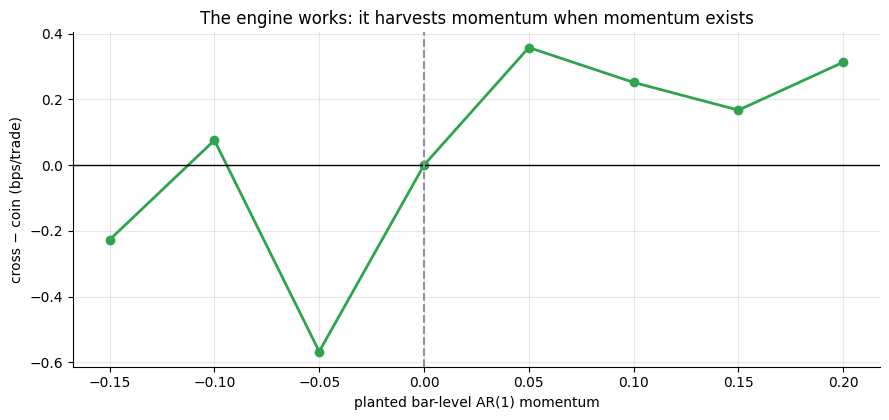

At momentum 0 the edge is ~0; it rises with persistence and is negative under reversion.


In [6]:
moms = [-0.15,-0.10,-0.05,0.0,0.05,0.10,0.15,0.20]
edge = []
for m in moms:
    b,_ = data.synthetic_5m(n_days=120, momentum=m, seed=72)
    ent = st.crossover_entries(b['close'])
    c = st.summarize(st.run_trades(b,ent,tp_R=1,sl_R=1,cost_bps=0),'ret_gross')['mean_bps']
    r = st.summarize(st.run_trades(b,ent,tp_R=1,sl_R=1,cost_bps=0,
        directions=st.random_directions(len(ent),seed=1)),'ret_gross')['mean_bps']
    edge.append(c-r)
fig, ax = plt.subplots(figsize=(9.0,4.3))
ax.plot(moms, edge, 'o-', c=GREEN, lw=2)
ax.axhline(0, c='k', lw=1); ax.axvline(0, ls='--', c=GREY)
ax.set_xlabel('planted bar-level AR(1) momentum'); ax.set_ylabel('cross − coin (bps/trade)')
ax.set_title('The engine works: it harvests momentum when momentum exists')
plt.tight_layout(); plt.show()
print('At momentum 0 the edge is ~0; it rises with persistence and is negative under reversion.')

The crossover advantage is monotone in the planted momentum and crosses zero right at a martingale — so the engine is a faithful momentum detector. The real-tape verdict is therefore a statement about the **market**, not the method: at 5-minute fidelity there is no momentum here to harvest. Forks worth trying: an explicit reversal sign ([Rip-Tide](../../32-rip-tide/)), an intraday-momentum *time window* (Gao et al. 2018) rather than every cross, or a higher timeframe ([Fools-Gold](../../21-fools-gold/)).